#####**Observação:** É necessário carregar benchmark do experiment Daskmodin

#**Benchmark & Pipeline ML — NYC Taxi**
####Trabalho realizado para disciplina de Ciência de Dados em Larga Escala
#####**Grupo:** Renata Azevedo (up202512262), Giuliano (up202512089) e Ni (up202205842)

9.   **Experimento 3 - Joblib**


Joblib é uma biblioteca do ecossistema Python orientada para a execução eficiente de tarefas e pipelines computacionais, sendo amplamente utilizada em Machine Learning, especialmente em conjunto com scikit-learn.

Neste experimento, o JobLib foi utilizado em modo sequencial (n_jobs=1), servindo como baseline para comparação com abordagens paralelas e distribuídas.


Logo:
- Não utiliza múltiplos núcleos da CPU
- Executa tarefas de forma linear (uma de cada vez)
- Mantém a mesma estrutura de pipeline do JobLib
- Permite comparar diretamente com versões paralelas e outras bibliotecas

Tem Overhead reduzido, pois não existe custo de criação de processos paralelos, e menor complexidade de execução comparado com frameworks distribuídos.

>9.1.   **Configuração do Ambiente**


Instalação da biblioteca de processamento de dados:

In [1]:
# ============================================================
# INSTALAÇÕES — execute apenas uma vez no Colab
# Descomente as linhas necessárias e volte a comentar após instalar
# ============================================================

# !pip install dask[complete] pyarrow          # Dask
#!pip install modin[ray]                      # Modin (backend Ray)
# !pip install pyspark                         # PySpark / Koalas
# !pip install xgboost                         # XGBoost
# !pip install yappi                           # Profiling multi-thread
#!pip install modin[dask]
# RAPIDS (só com GPU NVIDIA no Colab — ativar runtime GPU primeiro):
#!pip install cudf-cu12 cuml-cu12 --extra-index-url=https://pypi.nvidia.com

print("OK.")

OK.


Iniciando a leitura com algumas importações necessárias:

In [2]:
#============================================================
# IMPORTS GERAIS
# ============================================================
import os, time, warnings, urllib.request, gc
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

print(f"Pandas  : {pd.__version__}")
print(f"NumPy   : {np.__version__}")
print(f"Data    : {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Pandas  : 2.2.2
NumPy   : 2.0.2
Data    : 2026-06-03 20:38


In [3]:
# ============================================================
# IMPORTS DAS BIBLIOTECAS BIG DATA
# try/except: o notebook não quebra se uma lib não estiver instalada
# ============================================================

# Injeta dicionário vazio para compatibilidade do Spark com Pandas recente
if not hasattr(pd.core.common, '_builtin_table'):
    pd.core.common._builtin_table = {}

# --- JobLib (já incluído no Scikit-learn, mas importamos explicitamente) ---
try:
    import joblib
    from joblib import Parallel, delayed
    print(f" JobLib      : {joblib.__version__}")
    JOBLIB_AVAILABLE = True
except ImportError:
    print(" JobLib não disponível")
    JOBLIB_AVAILABLE = False


# --- Scikit-learn ---
try:
    import sklearn
    print(f" Scikit-learn: {sklearn.__version__}")
except ImportError:
    print(" Scikit-learn não disponível")

 JobLib      : 1.5.3
 Scikit-learn: 1.6.1


In [4]:
# ============================================================
# CONFIGURAÇÃO GLOBAL
# Altere apenas estas variáveis para escalar o experimento
# ============================================================

ANO       = 2026   # Ano dos dados NYC Taxi
NUM_MESES = 2      # Número de meses a descarregar (1 = ~61 MB; 12 = ~730 MB)
caminho   = Path("./FileStore/taxi/csv2026")  # Pasta local dos dados

caminho.mkdir(parents=True, exist_ok=True)
print(f" Pasta: {caminho.resolve()}")
print(f" Período: {ANO}, meses 1 a {NUM_MESES}")

 Pasta: /content/FileStore/taxi/csv2026
 Período: 2026, meses 1 a 2


In [5]:
# Lista os ficheiros se a pasta existir
if caminho.exists():
    ficheiros = list(caminho.iterdir())
    if ficheiros:
        for f in ficheiros:
            print(f.name)
    else:
        print("A pasta está vazia.")
else:
    print("A pasta ainda não foi criada.")

A pasta está vazia.


In [6]:
opener = urllib.request.build_opener()
opener.addheaders = [
    ('User-Agent',
     'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36')
]
urllib.request.install_opener(opener)

In [7]:
# ============================================================
# DOWNLOAD AUTOMÁTICO DOS FICHEIROS PARQUET
# Parquet é um formato colunar — muito mais eficiente que CSV
# para as leituras parciais que o Dask/Spark fazem.
# ============================================================

url_loc = {} # Mapeia a URL de download para o caminho do ficheiro



for year in range(2026, 2027):
    for m in range(1, 3):
        month = "{:02d}".format(m)

        # 1. URL dinâmica com base nas variáveis do loop (Aponta para o .parquet real de cada mês)
        url = f"https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_{year}-{month}.parquet"

        # 2. Nome do ficheiro local atualizado para refletir a extensão correta (.parquet)
        fname = f"yellow_tripdata_{year}-{month}.parquet"

        # Como está no Windows (caminho atual), o destino aponta para a pasta local criada
        loc = f"./FileStore/taxi/csv2026/{fname}"

        # Guarda no dicionário
        url_loc[url] = loc

In [8]:
# 3. Executa o loop de download corrigido
for url, loc in url_loc.items():
    if Path(loc).exists():
        mb = Path(loc).stat().st_size / 1e6
        print(f" Já existe: {Path(loc).name} ({mb:.1f} MB)")
        continue
    try:
        print(f"⬇  A descarregar: {url} ...")
        urllib.request.urlretrieve(url, loc)
        mb = Path(loc).stat().st_size / 1e6
        print(f"   Guardado: {mb:.1f} MB")
    except Exception as e:
        print(f" Erro: {e}")

print("Processo de download concluído!")


⬇  A descarregar: https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2026-01.parquet ...
   Guardado: 64.2 MB
⬇  A descarregar: https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2026-02.parquet ...
   Guardado: 58.7 MB
Processo de download concluído!


9.2   **Início das Operações**

Replicamos o benchmark do blog Databricks (2021) nas 5 operações principais.


In [9]:
resultados = []   # lista global: (operação, biblioteca, tempo_s)

In [10]:
def benchmark(name, func):
    start = time.time()
    result = func()
    end = time.time()

    print(f"{name}: {end - start:.4f} sec")
    return result

In [11]:
def benchmark_pandas(folder_path: Path):
    print("Iniciando leitura com Pandas...")

    start = time.perf_counter()

    dfs = []
    for f in folder_path.glob("*.parquet"):
        dfs.append(pd.read_parquet(f))

    df = pd.concat(dfs, ignore_index=True)

    elapsed = time.perf_counter() - start

    print("\nResultado Pandas:")
    print(f"- Linhas: {len(df)}")
    print(f"- Colunas: {df.shape[1]}")
    print(f"- Tempo: {elapsed:.2f}s")
    resultados.append(('Task 1 - Leitura', 'Pandas', round(elapsed, 4)))  # substitui com o valor real
    return df, elapsed

In [12]:
# Define o caminho da pasta local onde os ficheiros estão a ser guardados
caminho = Path("./FileStore/taxi/csv2026")

# Lista o conteúdo da pasta
if caminho.exists():
    ficheiros = list(caminho.iterdir())
    if ficheiros:
        print(f"Encontrados {len(ficheiros)} ficheiro(s):")
        for f in ficheiros:
            print(f"- {f.name}")
    else:
        print("A pasta está vazia. Precisa de executar o loop de download primeiro!")
else:
    print("A pasta ainda não existe no caminho atual.")

Encontrados 2 ficheiro(s):
- yellow_tripdata_2026-02.parquet
- yellow_tripdata_2026-01.parquet



>9.2.1  **Task 1 — Leitura dos Dados (*Reading*)**


In [13]:


if JOBLIB_AVAILABLE:

    def ler_parquet(caminho_f):
        return pd.read_parquet(caminho_f)

    # Se tiveres vários ficheiros (igual ao conceito JobLib)
    lista_f = [str(f) for f in sorted(caminho.glob("*.parquet"))]

    # fallback caso só haja 1 ficheiro
    if len(lista_f) == 0:
        lista_f = [caminho]

    # ============================================================
    # LEITURA SEQUENCIAL (baseline)
    # ============================================================

    start = time.perf_counter()
    dfs_seq = [ler_parquet(f) for f in lista_f]
    df_job = pd.concat(dfs_seq, ignore_index=True)
    t_job_seq = time.perf_counter() - start

    print(f"JobLib (sequencial): {len(df_job):,} linhas em {t_job_seq:.2f}s")

    resultados.append(('Task 1 - Leitura', 'JobLib (seq)', round(t_job_seq, 4)))

else:
    print(" JobLib não disponível")

JobLib (sequencial): 7,124,755 linhas em 1.55s


In [14]:
df_job.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,7.2,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,7.9,4.25,0.5,0.00,0.0,1.0,13.65,2.5,0.0,0.75
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,10.7,4.25,0.5,2.50,0.0,1.0,18.95,2.5,0.0,0.75
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,38.7,1.00,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,13.5,1.00,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75


>9.2.2  **Task 2 — Agregações e Filtragem (*Aggregation & Filtering*)**


**Primeiro experimento:** Contagem de Valores. Contar quantas viagens ocorreram por tipo de pagamento.

In [15]:
# ── Task 2A: Value Counts  ─────
# Conta quantas viagens ocorreram por tipo de fornecedor.

print("─" * 45)
print("Task 2A — VALUE COUNTS (VendorID)")
print("─" * 45)


if JOBLIB_AVAILABLE:

    # ============================================================
    # FUNÇÃO BASE
    # ============================================================

    def value_counts_joblib():
        return df_job['VendorID'].value_counts()

    # ============================================================
    # SEQUENCIAL (baseline)
    # ============================================================

    start = time.perf_counter()
    vc_seq = value_counts_joblib()
    t_job_vc_seq = time.perf_counter() - start

    print(f"\nJobLib VC (seq): {t_job_vc_seq:.4f}s")
    print(vc_seq)

    resultados.append(('Task 2a - Value Counts', 'JobLib (seq)', round(t_job_vc_seq, 4)))

else:
    print(" JobLib não disponível")

─────────────────────────────────────────────
Task 2A — VALUE COUNTS (VendorID)
─────────────────────────────────────────────

JobLib VC (seq): 0.0328s
VendorID
2    5682159
1    1348034
7      84946
6       9616
Name: count, dtype: int64


**Segundo experimento:** GroupBy. Vamos calcular o valor médio da tarifa para cada tipo de fornecedor.

In [16]:
# ── Task 2B: GroupBy Mean  ─────
# Calcula a tarifa média (fare_amount) por tipo de fornecedor.
print("─" * 45)
print("Task 2B — GROUPBY MEAN (fare_amount por VendorID)")
print("─" * 45)


if JOBLIB_AVAILABLE:

    # ============================================================
    # FUNÇÃO BASE
    # ============================================================

    def groupby_joblib():
        return df_job.groupby('VendorID')['fare_amount'].mean()
    # ============================================================
    # SEQUENCIAL (baseline)
    # ============================================================

    start = time.perf_counter()
    mean_seq = groupby_joblib()
    t_job_mean_seq = time.perf_counter() - start

    print(f"\nTempo JobLib Groupby (seq): {t_job_mean_seq:.4f}s")
    print(mean_seq)

    resultados.append(('Task 2b - GroupBy', 'JobLib (seq)', round(t_job_mean_seq, 4)))

else:
    print(" JobLib não disponível")

─────────────────────────────────────────────
Task 2B — GROUPBY MEAN (fare_amount por VendorID)
─────────────────────────────────────────────

Tempo JobLib Groupby (seq): 0.1227s
VendorID
1    20.334299
2    21.513850
6     2.746568
7    16.559094
Name: fare_amount, dtype: float64


**Terceiro experimento:** Filtragem Complexa. Vamos filtrar apenas as viagens que tiveram mais de 2 passageiros e calcular a distância média percorrida para esse grupo específico.

In [17]:
# ── Task 2C: Filtragem Complexa ─
# Filtra viagens com mais de 2 passageiros e calcula distância média.
print("─" * 45)
print("Task 2C — FILTRAGEM (passenger_count > 2)")
print("─" * 45)

if JOBLIB_AVAILABLE:

    # ============================================================
    # FUNÇÃO BASE
    # ============================================================

    def filtro_joblib():
        return df_job[df_job['passenger_count'] > 2]['trip_distance'].mean()
    # ============================================================
    # SEQUENCIAL (baseline)
    # ============================================================

    start = time.perf_counter()
    filtro_seq = filtro_joblib()
    t_job_filtro_seq = time.perf_counter() - start

    print(f"\nTempo JobLib Filtro (seq): {t_job_filtro_seq:.4f}s  |  Distância média: {filtro_seq:.2f} milhas")
    print(filtro_seq)

    resultados.append(('Task 2c - Filtragem', 'JobLib (seq)', round(t_job_filtro_seq, 4)))

else:
    print(" JobLib não disponível")

─────────────────────────────────────────────
Task 2C — FILTRAGEM (passenger_count > 2)
─────────────────────────────────────────────

Tempo JobLib Filtro (seq): 0.0705s  |  Distância média: 3.72 milhas
3.7211737975852737


 ---
>9.2.3  **Task 3 — Join de Tabelas**


O benchmark Databricks faz um join para traduzir IDs em nomes de localização. O Koalas usa **Broadcast Join** internamente: clona a tabela pequena em cada executor e faz o join em memória local.

In [18]:
# ============================================================
# PREPARAÇÃO GLOBAL
# ============================================================

url_zonas = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"

try:
    df_zones_job = pd.read_csv(url_zonas)

    df_zones_job = df_zones_job.rename(
        columns={'LocationID': 'PULocationID'}
    )

except Exception as e:
    print(f"Erro ao descarregar zonas online: {e}")

    df_zones_p = pd.DataFrame({
        'PULocationID': range(1, 266),
        'Zone': [f'Zone {i}' for i in range(1, 266)]
    })

# lista de ficheiros parquet
lista_f = [str(f) for f in sorted(caminho.glob("*.parquet"))]

In [19]:
if JOBLIB_AVAILABLE:

    # ============================================================
    # FUNÇÃO JOIN
    # ============================================================

    def join_joblib():
        return df_job.merge(
            df_zones_job,
            on='PULocationID',
            how='left'
        )

    # ============================================================
    # SEQUENCIAL (baseline)
    # ============================================================

    start = time.perf_counter()

    df_final_seq = join_joblib()
    _ = df_final_seq.head(1)

    t_job_join_seq = time.perf_counter() - start

    print(f"Tempo Join (JobLib seq): {t_job_join_seq:.4f}s")

    resultados.append((
        'Task 3 - Join',
        'JobLib (seq)',
        round(t_job_join_seq, 4)
    ))

else:
    print(" JobLib não disponível")

Tempo Join (JobLib seq): 1.3147s


In [20]:
display(
    df_final_seq[
        ['PULocationID', 'Zone', 'fare_amount']
    ].head(3)
)

,PULocationID,Zone,fare_amount
0,239,Upper West Side South,7.2
1,163,Midtown North,7.9
2,43,Central Park,10.7



---
>9.2.4  **Task 4 — Cálculo Aritmético (*Arithmetic Calculation*)**

Cria nova coluna: gorjeta por passageiro (`tip_per_passenger = tip_amount / passenger_count`).

In [21]:
# ── Task 4: Cálculo (Joblib Sequencial) ───────────

print("─" * 45)
print("Task 4 — CÁLCULO ARITMÉTICO (tip/passageiro)")
print("─" * 45)

# Joblib (sequencial)
if JOBLIB_AVAILABLE:

    start = time.time()

    df_job['tip_per_passenger'] = (
        df_job['tip_amount'] /
        df_job['passenger_count'].replace(0, float('nan'))
    )

    t_job_calc_seq = time.time() - start

    print(f"Tempo Cálculo (JobLib Seq) : {t_job_calc_seq:.4f}s")

    resultados.append((
        'Task 4 - Cálculo',
        'JobLib (seq)',
        round(t_job_calc_seq, 4)
    ))

─────────────────────────────────────────────
Task 4 — CÁLCULO ARITMÉTICO (tip/passageiro)
─────────────────────────────────────────────
Tempo Cálculo (JobLib Seq) : 0.0487s


---
>9.2.5  **Task 5 — Escrita dos Dados (*Writing / Persistence*)**

Persistência dos resultados em formato Parquet.

In [22]:
# ── Task 5: Escrita (Joblib Sequencial) ───────────

print("─" * 45)
print("Task 5 — ESCRITA EM PARQUET")
print("─" * 45)

if JOBLIB_AVAILABLE:

    start = time.time()

    # Joblib sequencial (sem paralelização real aqui, mas mantido para consistência do benchmark)
    df_job.to_parquet('./resultado_joblib_seq.parquet', index=False)

    t_job_write_seq = time.time() - start

    print(f"Tempo Escrita (JobLib Seq) : {t_job_write_seq:.4f}s")

    resultados.append((
        'Task 5 - Escrita',
        'JobLib (seq)',
        round(t_job_write_seq, 4)
    ))

─────────────────────────────────────────────
Task 5 — ESCRITA EM PARQUET
─────────────────────────────────────────────
Tempo Escrita (JobLib Seq) : 4.1858s


---
10.   **Predição - Experimento**

>10.1 **Metodologia**


A metodologia deste projeto foi estruturada em um pipeline de engenharia de dados dividido em quatro etapas principais: preparação do ambiente, ingestão de dados, processamento multitecnologia e análise de performance.
>10.2 **Resultado e Análise**

In [23]:
tabela_pivot = pd.read_csv("benchmark_pivotdaskmodin.csv", index_col=0)

In [24]:
tabela_pivot.loc['Task 1 - Leitura', 'JobLib (seq)'] = t_job_seq
tabela_pivot.loc['Task 2a - Value Counts', 'JobLib (seq)'] = t_job_vc_seq
tabela_pivot.loc['Task 2b - GroupBy', 'JobLib (seq)'] = t_job_mean_seq
tabela_pivot.loc['Task 2c - Filtragem', 'JobLib (seq)'] = t_job_filtro_seq
tabela_pivot.loc['Task 3 - Join', 'JobLib (seq)'] = t_job_join_seq
tabela_pivot.loc['Task 4 - Cálculo', 'JobLib (seq)'] = t_job_calc_seq
tabela_pivot.loc['Task 5 - Escrita', 'JobLib (seq)'] = t_job_write_seq

In [25]:
# ============================================================
# Ratio Joblib/Pandas
# ============================================================

if 'JobLib (seq)' in tabela_pivot.columns and 'Pandas' in tabela_pivot.columns:
    tabela_pivot['Ratio JobLib (seq)/Pandas'] = (
        tabela_pivot['JobLib (seq)'] / tabela_pivot['Pandas']
    ).round(2)


# ============================================================
# mover  Vencedor para última coluna
# ============================================================

col_vencedor = tabela_pivot.pop(' Vencedor')
tabela_pivot[' Vencedor'] = col_vencedor

In [26]:
def winner(row):
    # colunas que NÃO podem entrar no cálculo
    ignore_cols = [' Vencedor'] + [c for c in row.index if 'Ratio' in c]

    vals = {
        k: v for k, v in row.items()
        if k not in ignore_cols
        and isinstance(v, (int, float))
        and pd.notna(v)
    }

    return min(vals, key=vals.get) if vals else '?'

tabela_pivot[' Vencedor'] = tabela_pivot.apply(winner, axis=1)
tabela_pivot.to_csv("benchmark_pivotjoblib.csv")
display(tabela_pivot)

,Dask,Koalas,Pandas,Ratio Dask/Pandas,Ratio Koalas/Pandas,Modin,Ratio Modin/Pandas,DaskModin,Ratio DaskModin/Pandas,JobLib (seq),Ratio JobLib (seq)/Pandas,Vencedor
Operação,,,,,,,,,,,,
Task 1 - Leitura,4.5869,10.6917,2.6898,1.71,3.97,13.918374,5.17,7.451377,2.77,1.550586,0.58,JobLib (seq)
Task 2a - Value Counts,0.3964,0.1854,0.0840,4.72,2.21,1.312871,15.63,0.716981,8.54,0.032806,0.39,JobLib (seq)
Task 2b - GroupBy,0.7616,0.1631,0.2433,3.13,0.67,3.144301,12.92,0.459600,1.89,0.122655,0.50,JobLib (seq)
Task 2c - Filtragem,0.7406,1.5335,0.1718,4.31,8.93,11.008595,64.08,0.751710,4.38,0.070488,0.41,JobLib (seq)
Task 3 - Join,2.4821,0.6970,2.3380,1.06,0.30,312.869694,133.82,17.245725,7.38,1.314699,0.56,Koalas
Task 4 - Cálculo,0.7859,0.2306,0.1014,7.75,2.27,51.565534,508.54,0.227336,2.24,0.048656,0.48,JobLib (seq)
Task 5 - Escrita,11.4636,32.1130,6.6672,1.72,4.82,9.390804,1.41,7.852370,1.18,4.185805,0.63,JobLib (seq)


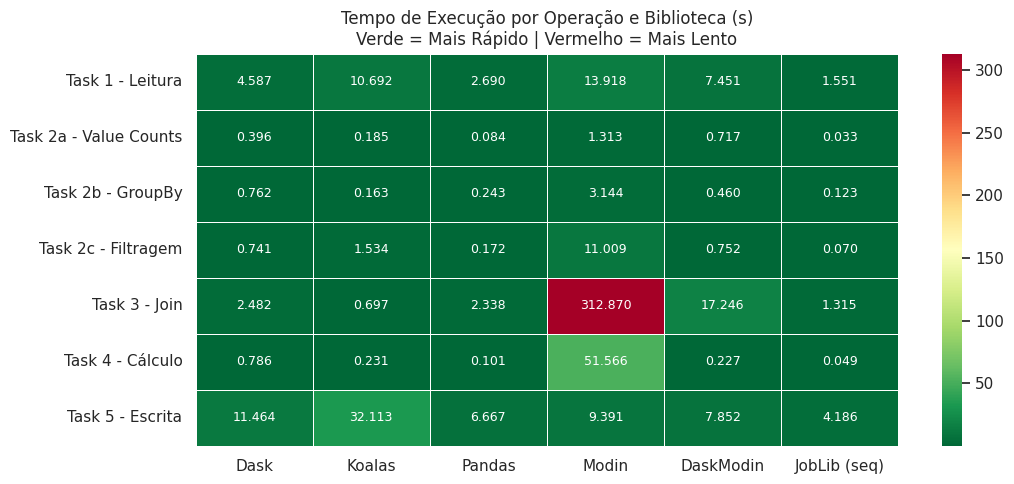

 Guardado: heatmap_exp1joblib.png


In [27]:
# ── Heatmap Visual  ───
fig, ax = plt.subplots(figsize=(11, 5))
cols_num = [c for c in tabela_pivot.columns if c not in [' Vencedor'] and 'Ratio' not in c]
dados_heat = tabela_pivot[cols_num].fillna(tabela_pivot[cols_num].max().max())
sns.heatmap(dados_heat, annot=True, fmt='.3f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Tempo de Execução por Operação e Biblioteca (s)\nVerde = Mais Rápido | Vermelho = Mais Lento', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('./heatmap_exp1joblib.png', dpi=150)
plt.show()
print(" Guardado: heatmap_exp1joblib.png")

**Análise de Resultados — Experimento 3:**

Os resultados indicam que o JobLib sequencial apresenta desempenho competitivo em várias operações do benchmark, especialmente em tarefas de transformação e filtragem de dados.

Esse comportamento pode ser explicado por:

- Execução direta em memória local
- Ausência de overhead de paralelização

Ao contrário de Spark, Dask ou Modin, o JobLib sequencial não necessita de:

- criar clusters
- gerir partições complexas
- construir task graphs distribuídos

Isto reduz significativamente os custos de coordenação.

Com um dataset de aproximadamente 120 MB, o trabalho cabe facilmente na RAM não existe necessidade de distribuição entre máquinas.





Mesmo sem otimizações de paralelismo, o JobLib apresenta comportamento consistente, servindo como referência útil para comparação com abordagens paralelas e distribuídas.

**Próximo Notebook:**

 3.1-experimento_JobLib_paralelo.ipynb - Paralelização com Joblib